# Pre-Processing and Modeling
## Overview / assumptions

These are interventional simulations (not causal proofs). They assume that the model approximates how risk changes when covariates change — results are estimates, not definitive causal effects.

We avoid conditioning on colliders. When simulating an upstream policy, don’t include downstream variables that lie on the causal path as adjustment variables.

Use train the CatBoost model on Label Encoded TRAINING DATA and use this as the baseline to evaluate various policy interventions. 

We report uncertainty (bootstrap or Monte Carlo) and report absolute and relative changes in expected smokers, and subgroup effects (by age/income).

### 1. Import data

In [8]:
#import cleaned_Data_splits_with_NaN.pkl file
import pickle
with open('../data/modeling/part2/cleaned_data_splits_with_NaN.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_train = data_splits['X_train_with_NaN']
X_test = data_splits['X_test_with_NaN']
y_train = data_splits['y_train_clean']
y_test = data_splits['y_test_clean']
X_combined_with_NaN = data_splits['X_combined_with_NaN']
y_combined = data_splits['y_combined']


In [9]:
#import nominal and ordinal features for future use
import pickle
with open('../data/modeling/part2/nominal_ordinal_features.pkl', 'rb') as f:
    features = pickle.load(f)
nominal_features = features['nominal_features']
ordinal_features = features['ordinal_features']


### 2. Train a baseline model

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool
import shap
import numpy as np
import time

# Ordinal features → Int64 (nullable integer type)
for col in ordinal_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('Int64')
        X_test[col] = X_test[col].astype('Int64')

# Nominal features → convert to string and replace NaN with "Unknown"
for col in nominal_features:
    X_train[col] = (
        X_train[col].astype(str).replace("nan", "Unknown")
    )
    X_test[col] = (
        X_test[col].astype(str).replace("nan", "Unknown")
    )


In [ ]:


# Train CatBoost model
model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
cat_features=nominal_features)
# Wrap your data in a Pool
# train_pool = Pool(data=X_combined_with_NaN, label=y_combined, cat_features=nominal_features)
train_pool = Pool(X_train, y_train, cat_features=nominal_features)
test_pool  = Pool(X_test, y_test, cat_features=nominal_features)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    verbose=100,
    plot=False
)
start = time.time()
# Training
model.fit(train_pool)
# model.fit(...)
end = time.time()

# Save the trained model
model.save_model('../data/modeling/part2/001_baseline_catboost_model.cbm')

# for col in catboost_categorical_cols:
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat = model.predict(X_test)
y_proba_cat = model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_time = end - start

## Scenario 1 — “Expand Mental Health Access”

**Goal:** _Reduce smoking by improving population mental health (MENTHLTH)._ <br>
**Rationale:** _MENTHLTH showed the largest confounding effect (up to ~28% change). Improving mental health should lower smoking propensity_.

### Intervention rule (synthetic):

For people in lowest two income groups (_INCOMG levels 1 & 2), reduce MENTHLTH measure by 20-70% (e.g. move categorical mental-health scores one level towards "better").

We shift some % of respondents coded poor → fair, fair→good (stochastic selection within target group) based on the selected sensitivity level.

### Metrics to report

expected_smokers_base and expected_smokers_sim (absolute counts)

Absolute and percent reduction

Stratified results for _INCOMG groups

95% CI via bootstrap: resample rows with replacement, recompute predicted sums 1000x

### Caveats

If MENTHLTH is a mediator of income → smoking, changing it simulates a direct policy on mental health (which is exactly what we want). If it is partly caused by smoking, some reverse causality may bias estimates.

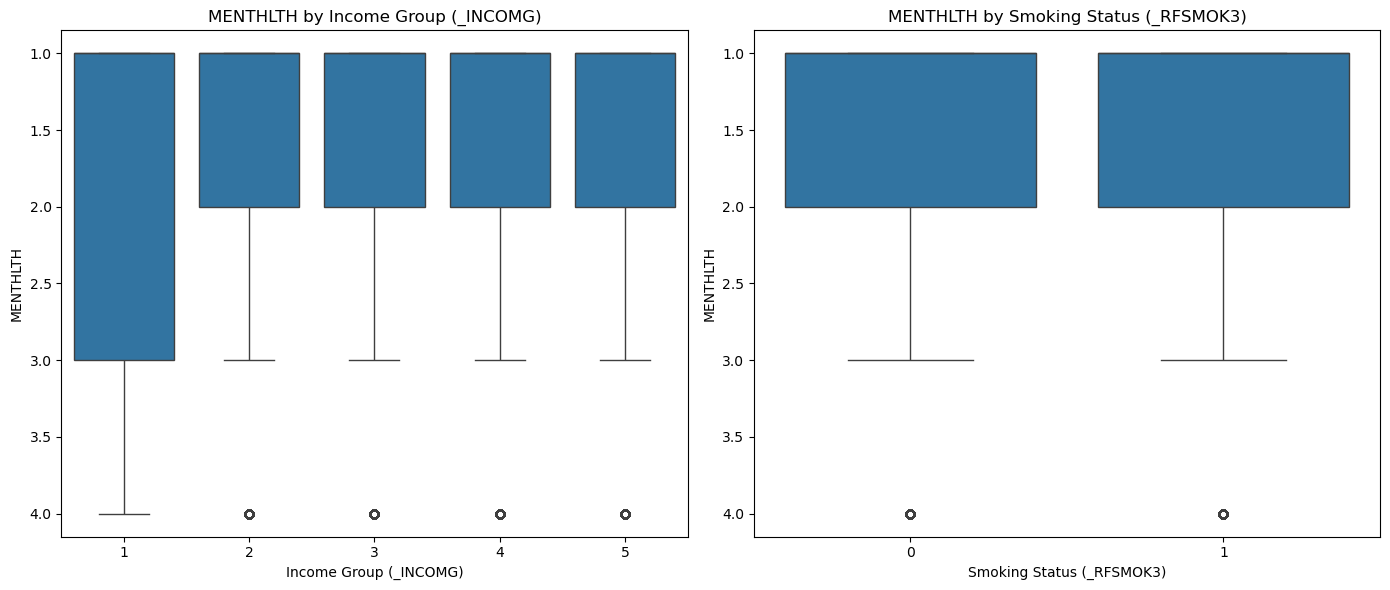

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: MENTHLTH by _INCOMG
sns.boxplot(x='_INCOMG', y='MENTHLTH', data=X_train, ax=axes[0])
axes[0].set_title('MENTHLTH by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('MENTHLTH')

# Boxplot: MENTHLTH by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='MENTHLTH', data=train_df, ax=axes[1])
axes[1].set_title('MENTHLTH by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('MENTHLTH')

plt.tight_layout()
plt.show()

## Scenario 2 — “Education Uplift Program”

**Goal:** _Simulate the impact of improving education (health literacy / adult education) in low-income groups._ <br>
**Rationale:** _ _EDUCAG showed up to ~29% effect on the income coefficient — biggest lever found._

### Intervention rule:

For _INCOMG = 1 & 2, upgrade one education level for 20% of respondents (e.g., Less than HS → High School or HS → Some College). This is a synthetic proxy for adult education / literacy programs.

### Metrics & checks

Absolute and percent change in expected smokers overall and within _INCOMG groups.

Evaluate distributional effects: does benefit concentrate in certain ages?

Sensitivity: vary upgrade fraction (10%, 20%, 50%) and compare. (Maybe)

### Caveats

Education is long-term; real-world effect sizes may be delayed. This simulation represents an immediate change in the predictor and estimates short-term impact under the model.

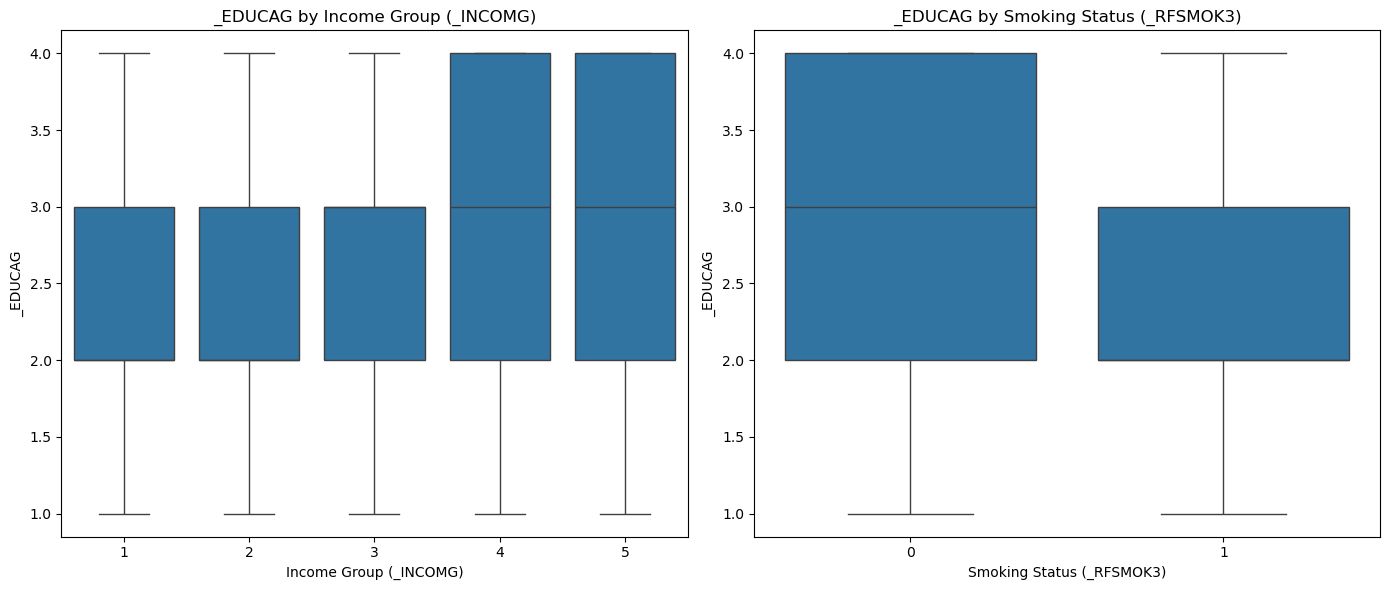

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: _EDUCAG by _INCOMG
sns.boxplot(x='_INCOMG', y='_EDUCAG', data=X_train, ax=axes[0])
axes[0].set_title('_EDUCAG by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('_EDUCAG')

# Boxplot: _EDUCAG by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='_EDUCAG', data=train_df, ax=axes[1])
axes[1].set_title('_EDUCAG by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('_EDUCAG')

plt.tight_layout()
plt.show()

## Scenario 3 — “Remove Medical Cost Barriers + Insurance Outreach”

**Goal:** _Reduce smoking by lowering reported medical cost barriers (MEDCOST) and increasing perceived insurance access (HLTHPLN1) in low/mid-income groups. We observe a improvement in GENHLTH which has also been modeled._ <br>
**Rationale:** _MEDCOST , HLTHPLN1 and GENHLTH changed the income coefficient 11–21% — an actionable policy lever (subsidies, free cessation treatment)._

### Intervention rule:

For _INCOMG in [1,2,3], 

1. Set MEDCOST -> No barrier for 20% of those who reported cost barrier. For same groups, flip HLTHPLN1 to insured for 20% (simulate outreach/coverage). GENHLTH as a result of improved MEDCOST and HLTHPLN1 by 40%. These ratios are picked up from the Confounder Analysis in EDA step.

2. Set MEDCOST -> No barrier for 20% of those who reported cost barrier. For same groups, flip HLTHPLN1 to insured for 30% (simulate outreach/coverage). GENHLTH as a result of improved MEDCOST and HLTHPLN1 by 50%. These ratios are picked up from the Confounder Analysis in EDA step.

### Metrics

Expected smokers baseline vs simulated

Subgroup breakdown by income level and by whether they received benefit

Cost-effectiveness estimate (if you can attach program cost per person)

### Caveats

MEDCOST and HLTHPLN1 and ripple effect of GENHLTH may be mediators of income; changing them simulates direct access interventions (e.g., free cessation services) — good policy-relevant scenario.

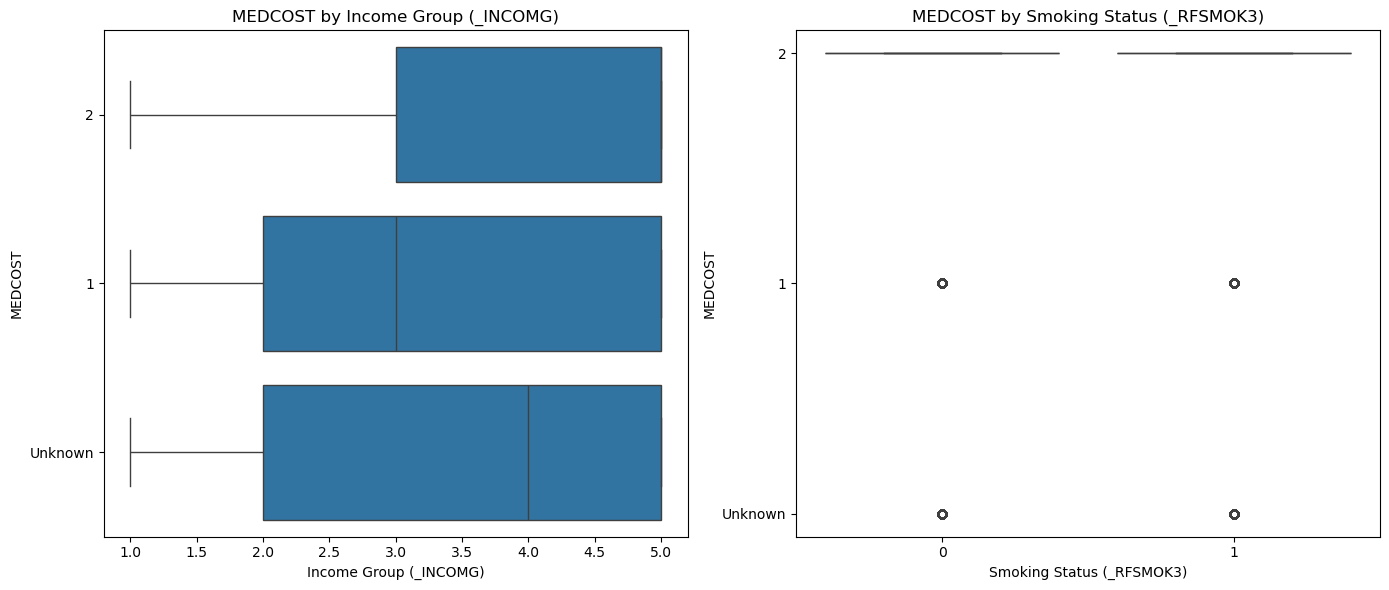

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: MEDCOST by _INCOMG
sns.boxplot(x='_INCOMG', y='MEDCOST', data=X_train, ax=axes[0])
axes[0].set_title('MEDCOST by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('MEDCOST')

# Boxplot: MEDCOST by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='MEDCOST', data=train_df, ax=axes[1])
axes[1].set_title('MEDCOST by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('MEDCOST')

plt.tight_layout()
plt.show()

### Results Presentation

For each scenario we produce:

**Table:** _baseline expected smokers, simulated expected smokers, absolute delta, % change, 95% CI (bootstrap)._

**Plot:** _bar chart of synthetic data imputation for specific scenario; expected smokers by _INCOMG groups (baseline vs simulated)._

**Tornado plot:** _sensitivity of outcomes to intervention intensity (e.g., 10/20/50% uptake)._

### Uncertainty & robustness 

**Bootstrap:** _Resample rows (or strata) 1,000 times, recompute expected smokers for baseline & each scenario, report 95% CI._

**Mediation check:** _If variable might be a mediator, compare (a) effect when you intervene on mediator directly (simulate), and (b) effect when you re-fit the model after changing mediator (structural change). The difference suggests indirect effects vs model artifacts._

In [11]:
"""
Policy Simulation Script (Scenarios A, B, C)
============================================
This script runs three policy simulation scenarios using the
baseline CatBoost model you trained and saved earlier:

 A) Mental Health Improvement
 B) Education Uplift
 C) Medical Cost & Insurance Outreach

We consolidate shared functions/utilities so scenarios remain clean.
"""

# =========================
# Setup
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
from catboost import CatBoostClassifier

RNG_SEED = 42
np.random.seed(RNG_SEED)
warnings.filterwarnings("ignore")

# =========================
# Data and Model
# =========================
# Use the combined dataset for simulation (full population)
#df = X_combined_with_NaN.join(y_combined).copy()
df = X_test.join(y_test).copy()

print(len(df), "rows in simulation dataset")


EXPOSURE = "_INCOMG"
OUTCOME  = "_RFSMOK3"

# Load your baseline CatBoost model (same one used in training)
model = CatBoostClassifier()
model.load_model("../data/modeling/part2/001_baseline_catboost_model.cbm")

MODEL_TYPE = "catboost"
model_features = model.feature_names_

# =========================
# Utilities
# =========================
"""Helper to make sure _RFSMOK3 is numeric 0/1 float"""
def ensure_numeric_outcome(df, outcome_col):
    """Ensure outcome is numeric 0/1 float."""
    if pd.api.types.is_categorical_dtype(df[outcome_col].dtype):
        df[outcome_col] = df[outcome_col].astype(int)
    df[outcome_col] = pd.to_numeric(df[outcome_col], errors="coerce").astype(float)
    return df

"""Helper to make sure features are encoded correctly before feeding into model predictor"""
def fix_dtypes(df, model_features, nominal_features, ordinal_features):
    """Fix dtypes to match training."""
    for col in model_features:
        if col in nominal_features and col in df.columns:
            df[col] = df[col].astype(str).replace("nan", "Unknown")
        elif col in ordinal_features and col in df.columns:
            df[col] = df[col].astype('Int64')
    return df

"""Helper to predict probabilities from CatBoost Model"""
def predict_probs(model, X):
    """Unified prediction API."""
    if MODEL_TYPE == "catboost":
        return model.predict_proba(X)[:, 1]
    else:
        raise ValueError("Unsupported model type.")

"""Compute total expected smokers from predicted probabilities"""
def expected_smokers_from_probs(probs):
    """Expected number of smokers = sum of predicted probabilities."""
    return probs.sum()

"""Helper to compute bootstrap CI for delta smokers"""
def bootstrap_delta(model, X_base, X_sim, model_features, n_boot=300):
    """Bootstrap CI for delta smokers between baseline and scenario."""
    n = len(X_base)
    deltas = []
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True)
        Xb = X_base.iloc[idx][model_features]
        Xs = X_sim.iloc[idx][model_features]
        pb = predict_probs(model, Xb)
        ps = predict_probs(model, Xs)
        deltas.append(ps.sum() - pb.sum())
    return np.percentile(deltas, [2.5, 50, 97.5])

"""Helper to view changes by strata (e.g. income group)"""
def stratified_summary(df_base, probs_base, df_sim, probs_sim, stratify_col):
    """Summarize baseline vs scenario smokers by strata (e.g. income)."""
    rows = []
    for grp, idx in df_base.groupby(stratify_col).groups.items():
        base_sum = probs_base.loc[idx].sum()
        sim_sum  = probs_sim.loc[idx].sum()
        rows.append({
            stratify_col: grp,
            "baseline": base_sum,
            "scenario": sim_sum,
            "delta": sim_sum - base_sum,
            "pct_change": 100*(sim_sum - base_sum)/base_sum if base_sum > 0 else np.nan
        })
    return pd.DataFrame(rows)


# =========================
# Baseline Prediction
# =========================
df = ensure_numeric_outcome(df, OUTCOME)
df = fix_dtypes(df, model_features, nominal_features, ordinal_features)

# Extract features for baseline prediction
X_base = df[model_features].copy()

# Predict baseline probabilities
p_base = predict_probs(model, X_base)
expected_base = expected_smokers_from_probs(p_base)

df_base = df.copy()
df_base["p_base"] = p_base

print(f"Baseline expected smokers (population): {expected_base:,.0f}")


462303 rows in simulation dataset
Baseline expected smokers (population): 187,338


In [12]:
len(df_base)

462303

## Scenario 1 - Mental Health Improvement

In [24]:
# =========================
# Scenario A: Mental Health Improvement
# =========================

def scenario_mental_health_improve(df_orig, pct_reduction, target_incomes=[1,2]):
    """
    Improve MENTHLTH for a fraction of low-income respondents.
    
    - MENTHLTH is ordinal categorical: 1=best, 4=worst.
    - For a pct_reduction of people in target_incomes,
      shift MENTHLTH down by 1 level (toward better).
    """
    df_sim = df_orig.copy()
    mask = df_sim["_INCOMG"].isin(target_incomes)

    # Work only on eligible rows
    idx_candidates = df_sim[mask].index

    n_change = int(len(idx_candidates) * pct_reduction)

    if n_change > 0:
        chosen = np.random.choice(idx_candidates, size=n_change, replace=False)
        # Shift 4→3, 3→2, 2→1; keep 1 unchanged
        df_sim.loc[chosen, "MENTHLTH"] = df_sim.loc[chosen, "MENTHLTH"].astype(int) - 1
        df_sim["MENTHLTH"] = df_sim["MENTHLTH"].clip(lower=1)

    return df_sim

# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario A
scenario_A_results = []
scenario_A_synthetic_dfs = []
for pct_change in [0.20, 0.50, 0.70]:
    df_a = scenario_mental_health_improve(df_base, pct_change)
    p_a = predict_probs(model, df_a[model_features])
    exp_a = expected_smokers_from_probs(p_a)
    ci_a = bootstrap_delta(model, df_base[model_features], df_a[model_features], model_features)

    print(f"Scenario A (Mental Health) % Pct Change :{pct_change}")
    print(f"Expected smokers: {exp_a:,.0f}, Δ={exp_a-expected_base:.0f}, 95% CI {ci_a}")

    p_base = pd.Series(p_base, index=df_base.index)
    p_a    = pd.Series(p_a, index=df_a.index)

    # Stratified by income
    result = stratified_summary(df_base, p_base, df_a, p_a, stratify_col=EXPOSURE)
    print(result)
    scenario_A_results.append(result)
    scenario_A_synthetic_dfs.append(df_a)




Scenario A (Mental Health) % Pct Change :0.2
Expected smokers: 187,203, Δ=-136, 95% CI [-140.4154335  -136.03139549 -131.13642442]
   _INCOMG      baseline      scenario      delta  pct_change
0        1  27661.897815  27599.700127 -62.197688   -0.224850
1        2  36184.896313  36111.161853 -73.734460   -0.203771
2        3  20744.133634  20744.133634   0.000000    0.000000
3        4  24350.929679  24350.929679   0.000000    0.000000
4        5  78396.641994  78396.641994   0.000000    0.000000
Scenario A (Mental Health) % Pct Change :0.5
Expected smokers: 186,993, Δ=-345, 95% CI [-352.80196759 -345.79077076 -337.7389533 ]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27503.841885 -158.055930   -0.571385
1        2  36184.896313  35997.511691 -187.384622   -0.517853
2        3  20744.133634  20744.133634    0.000000    0.000000
3        4  24350.929679  24350.929679    0.000000    0.000000
4        5  78396.641994  78396.641994    0.000000 

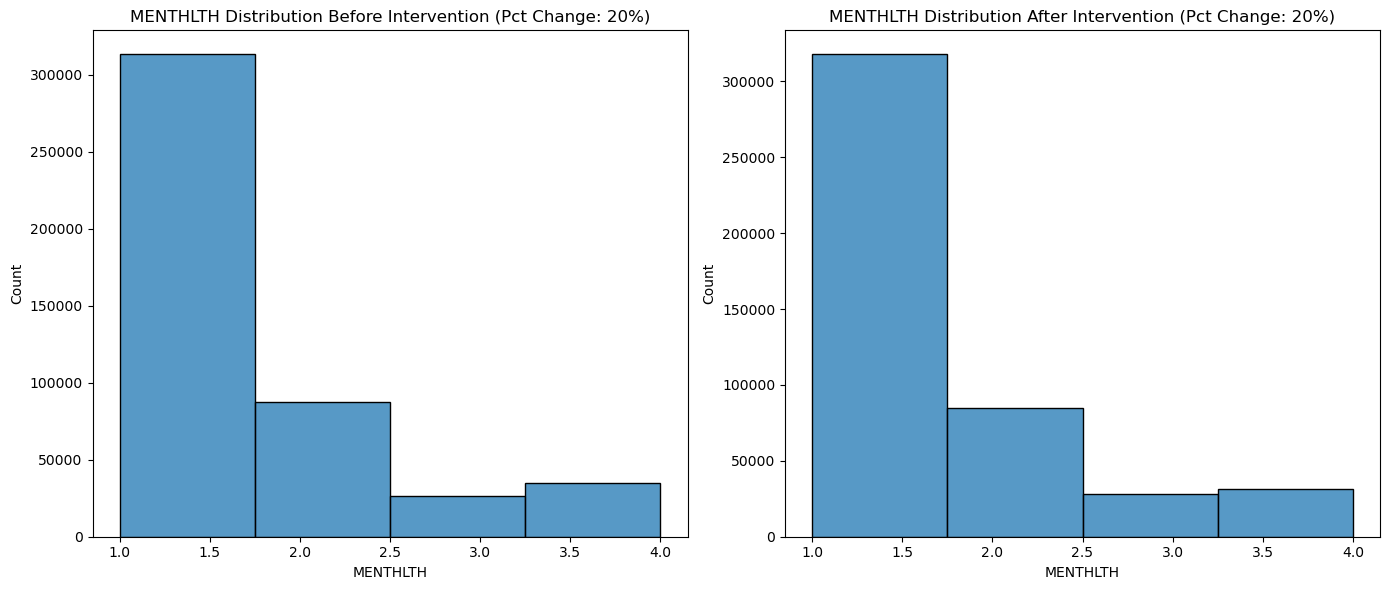

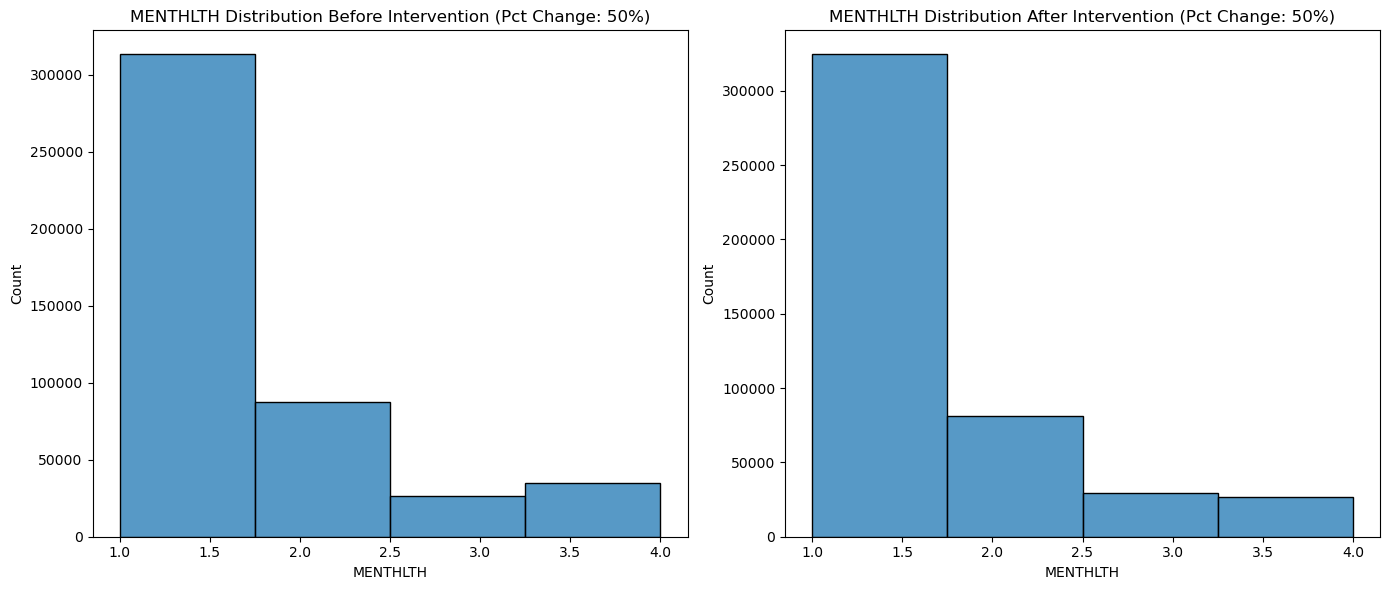

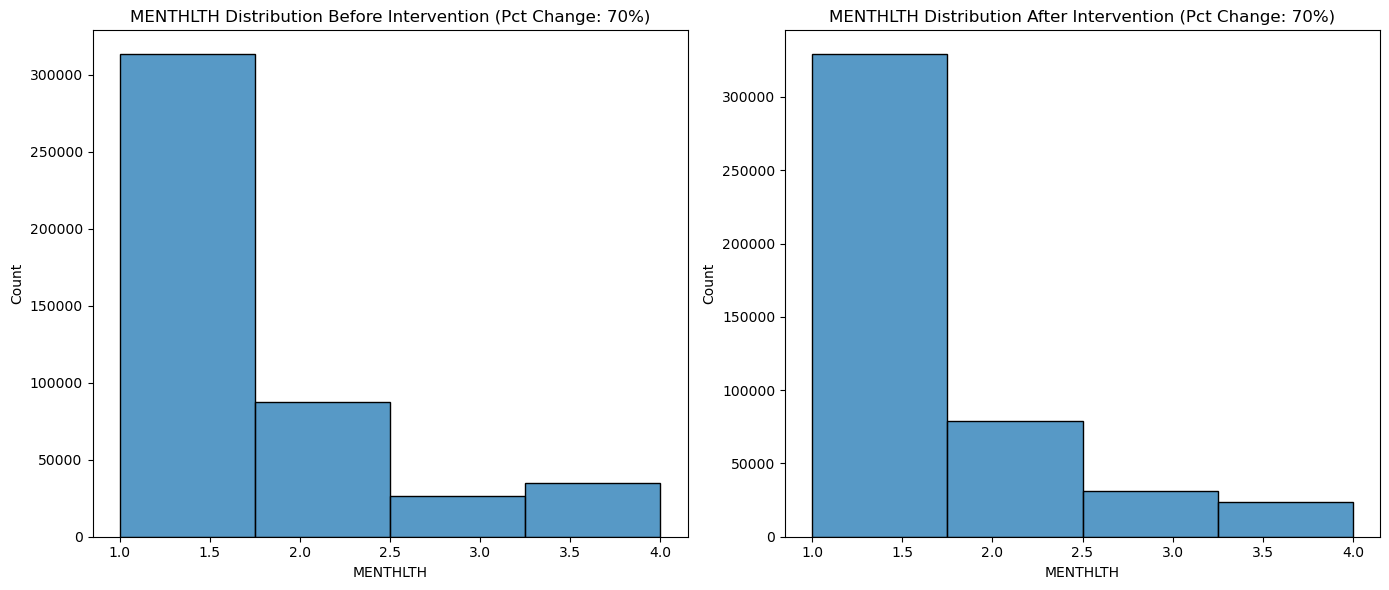

Scenario A (Mental Health Improvement) - Pct Change: 20%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 187,203
Delta Smokers: -136
Percentage Change in Smokers: -0.07%
--------------------------------------------------
Scenario A (Mental Health Improvement) - Pct Change: 50%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 186,993
Delta Smokers: -345
Percentage Change in Smokers: -0.18%
--------------------------------------------------
Scenario A (Mental Health Improvement) - Pct Change: 70%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 186,862
Delta Smokers: -477
Percentage Change in Smokers: -0.25%
--------------------------------------------------


In [28]:
# for each dataframe in scenario_results, plot distribution of MENTHLTH before and after intervention and show the % change in smokers and delta smokers

for i, pct_change in enumerate([0.20, 0.50, 0.70]):
    result = scenario_A_synthetic_dfs[i]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Distribution of MENTHLTH before intervention
    sns.histplot(df_base['MENTHLTH'], bins=4, kde=False, ax=axes[0])
    axes[0].set_title(f'MENTHLTH Distribution Before Intervention (Pct Change: {pct_change*100:.0f}%)')
    axes[0].set_xlabel('MENTHLTH')
    axes[0].set_ylabel('Count')

    # Distribution of MENTHLTH after intervention
    sns.histplot(result['MENTHLTH'], bins=4, kde=False, ax=axes[1])
    axes[1].set_title(f'MENTHLTH Distribution After Intervention (Pct Change: {pct_change*100:.0f}%)')
    axes[1].set_xlabel('MENTHLTH')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

    # print(f"Scenario A (Mental Health Improvement) - Pct Change: {pct_change*100:.0f}%")
    # print(result)

# =========================
#Show change in smokers before and after intervention
# =========================
for i, pct_change in enumerate([0.20, 0.50, 0.70]):
    result = scenario_A_results[i]
    total_baseline = result['baseline'].sum()
    total_scenario = result['scenario'].sum()
    delta_smokers = total_scenario - total_baseline
    pct_change_smokers = (delta_smokers / total_baseline) * 100 if total_baseline > 0 else np.nan

    print(f"Scenario A (Mental Health Improvement) - Pct Change: {pct_change*100:.0f}%")
    print(f"Total Baseline Smokers: {total_baseline:,.0f}")
    print(f"Total Scenario Smokers: {total_scenario:,.0f}")
    print(f"Delta Smokers: {delta_smokers:,.0f}")
    print(f"Percentage Change in Smokers: {pct_change_smokers:.2f}%")
    print("-" * 50)
# =========================




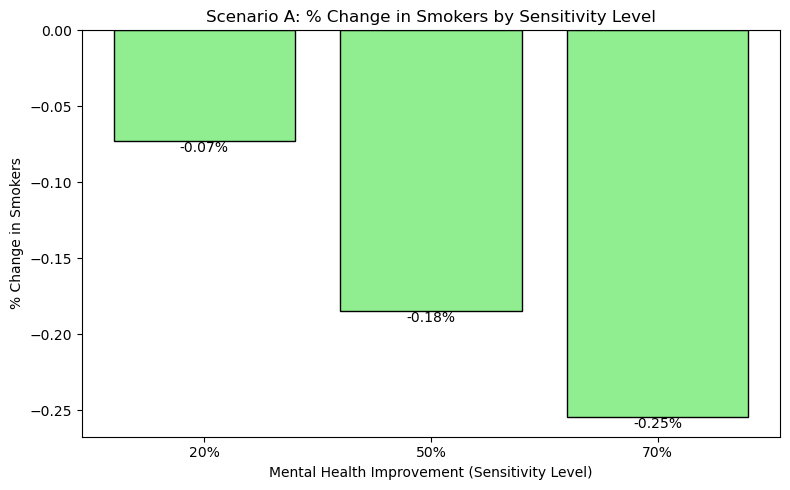

In [43]:
import numpy as np

import matplotlib.pyplot as plt

def calculate_pct_change(result):
    total_baseline = result['baseline'].sum()
    total_scenario = result['scenario'].sum()
    delta_smokers = total_scenario - total_baseline
    pct_change_smokers = (delta_smokers / total_baseline) * 100 if total_baseline > 0 else np.nan
    return pct_change_smokers

# Sensitivity levels and % change in smokers for Scenario A
sensitivity_levels = [20, 50, 70]
pct_changes = [
    calculate_pct_change(scenario_A_results[0]),
    calculate_pct_change(scenario_A_results[1]),
    calculate_pct_change(scenario_A_results[2])
]

colors = ['#90ee90' if v < 0 else '#ffcccb' for v in pct_changes]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    [f"{lvl}%" for lvl in sensitivity_levels],
    pct_changes,
    color=colors,
    edgecolor='black'
)
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylabel('% Change in Smokers')
plt.xlabel('Mental Health Improvement (Sensitivity Level)')
plt.title('Scenario A: % Change in Smokers by Sensitivity Level')
for bar, val in zip(bars, pct_changes):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}%", ha='center', va='bottom' if val > 0 else 'top')
plt.tight_layout()
plt.show()

### RESULTS - Scenario A: Mental Health Improvement

This scenario assesses the impact of improving mental health conditions across the population on smoking prevalence.

| **Pct Improvement** | **Baseline Smokers** | **Scenario Smokers** | **Δ Smokers** | **% Change** |
| ------------------- | -------------------- | -------------------- | ------------- | ------------ |
| 20%                 | 187,338              | 187,203              | -136          | **-0.07%**   |
| 50%                 | 187,338              | 186,993              | -345          | **-0.18%**   |
| 70%                 | 187,338              | 186,862              | -477          | **-0.25%**   |

### 1. Insights

1. The reduction in smokers is small but consistent with increasing levels of mental health improvement.
2. A 20% improvement in mental health corresponds to 136 fewer smokers, a 0.07% decline.
3. A 70% improvement produces the largest effect, with 477 fewer smokers (≈ 0.25% reduction).

The impact appears marginal, suggesting that mental health improvements alone may have limited direct influence on smoking behavior.

### 2. Interpretation

While mental health improvements show a positive direction (fewer smokers), the magnitude of change is modest.
This suggests:
1. Smoking behavior is multifactorial — influenced not only by mental health but also by education, income, social norms, and access to cessation programs.
2. Mental health support may play a supportive role but is not sufficient by itself to drive large reductions in smoking.

## Scenario 2 - Education Uplift

In [ ]:
# =========================
# Scenario B: Education Uplift
# =========================
def scenario_education_uplift(df_orig, uplift_frac, shift_levels=1, target_incomes=[1,2]):
    """
    Increase education (_EDUCAG) for a fraction of low-income respondents.
    
    - _EDUCAG is ordinal categorical: 1=lowest, 4=highest.
    - For an uplift_frac of people in target_incomes,
      shift _EDUCAG up by `shift_levels` (toward higher education),
      capped at 4 (highest level).
    """
    df_sim = df_orig.copy()
    mask = df_sim["_INCOMG"].isin(target_incomes)

    # Work only on eligible rows
    idx_candidates = df_sim[mask].index
    n_change = int(len(idx_candidates) * uplift_frac)

    if n_change > 0:
        chosen = np.random.choice(idx_candidates, size=n_change, replace=False)
        # Shift 1→2, 2→3, 3→4, 4→4 (capped)
        df_sim.loc[chosen, "_EDUCAG"] = (
            df_sim.loc[chosen, "_EDUCAG"].astype(int) + shift_levels
        ).clip(upper=4)

    return df_sim

# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario B
scenario_B_results = []
scenario_B_synthetic_dfs = []
for uplift_change in [0.20, 0.50, 0.70]:
    df_b = scenario_education_uplift(df_base, uplift_change , shift_levels=1)
    p_b = predict_probs(model, df_b[model_features])
    exp_b = expected_smokers_from_probs(p_b)
    ci_b = bootstrap_delta(model, df_base[model_features], df_b[model_features], model_features)

    print(f"Scenario B (Education Uplift)% Pct Change :{uplift_change}")
    print(f"Expected smokers: {exp_b:,.0f}, Δ={exp_b-expected_base:.0f}, 95% CI {ci_b}")

    p_base = pd.Series(p_base, index=df_base.index)
    p_b    = pd.Series(p_b, index=df_b.index)

    # Stratified by income
    result = stratified_summary(df_base, p_base, df_b, p_b, stratify_col=EXPOSURE)
    print(result)
    scenario_B_results.append(result)
    scenario_B_synthetic_dfs.append(df_b)



Scenario B (Education Uplift)% Pct Change :0.7
Expected smokers: 186,363, Δ=-975, 95% CI [-996.84460874 -976.09061382 -955.47842028]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27277.015148 -384.882667   -1.391382
1        2  36184.896313  35594.385300 -590.511013   -1.631927
2        3  20744.133634  20744.133634    0.000000    0.000000
3        4  24350.929679  24350.929679    0.000000    0.000000
4        5  78396.641994  78396.641994    0.000000    0.000000
Scenario B (Education Uplift)% Pct Change :0.7
Expected smokers: 184,895, Δ=-2444, 95% CI [-2478.12487963 -2443.24859585 -2413.44986381]
   _INCOMG      baseline      scenario        delta  pct_change
0        1  27661.897815  26707.651118  -954.246697   -3.449679
1        2  36184.896313  34695.333077 -1489.563236   -4.116533
2        3  20744.133634  20744.133634     0.000000    0.000000
3        4  24350.929679  24350.929679     0.000000    0.000000
4        5  78396.641994  78396.

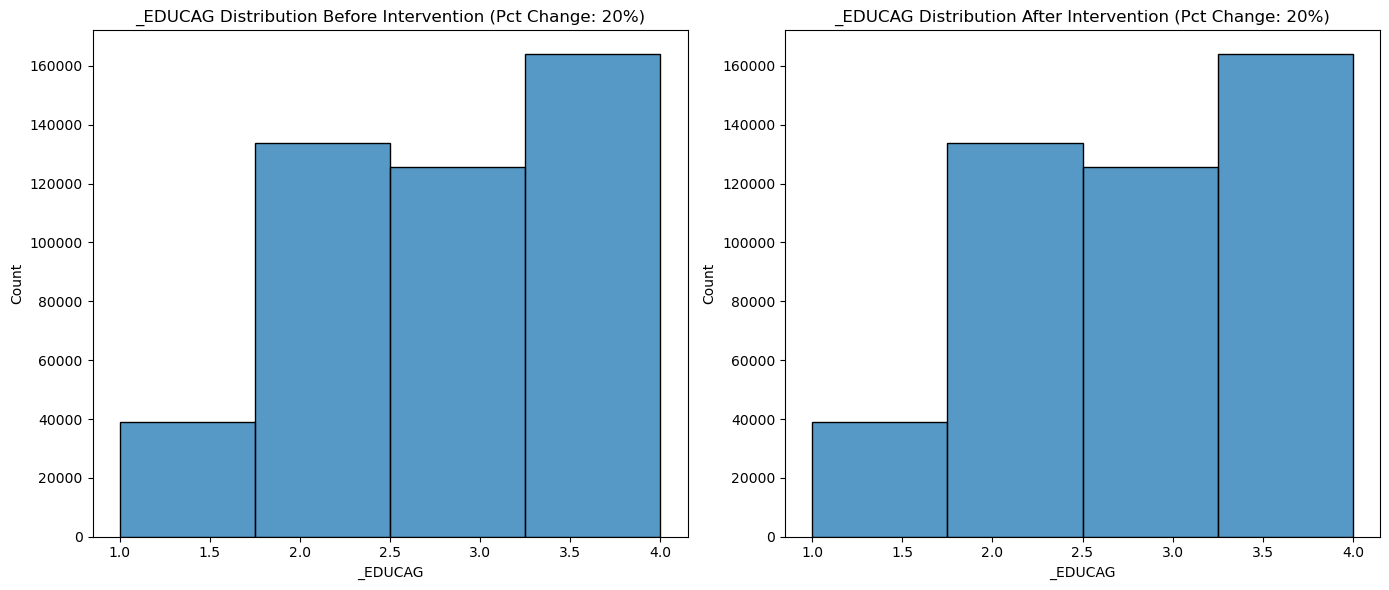

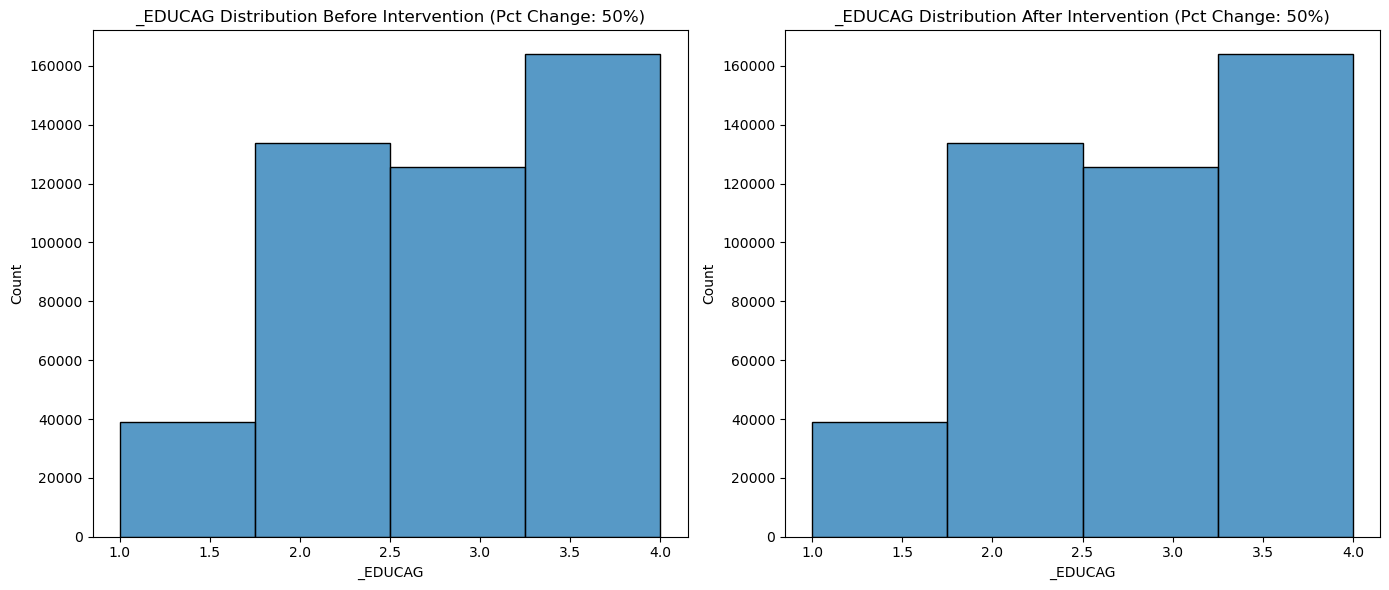

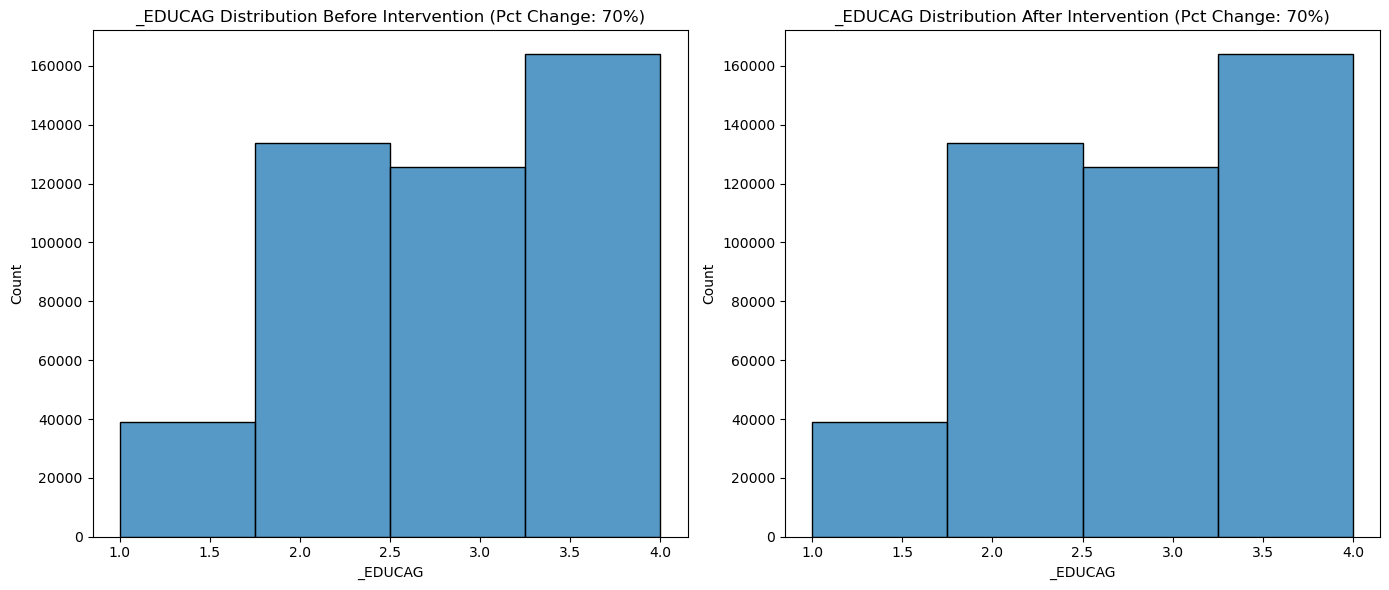

Scenario B ((Education Uplift) - Pct Change: 20%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 186,363
Delta Smokers: -975
Percentage Change in Smokers: -0.52%
--------------------------------------------------
Scenario B ((Education Uplift) - Pct Change: 50%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 184,895
Delta Smokers: -2,444
Percentage Change in Smokers: -1.30%
--------------------------------------------------
Scenario B ((Education Uplift) - Pct Change: 70%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 183,904
Delta Smokers: -3,435
Percentage Change in Smokers: -1.83%
--------------------------------------------------


In [37]:
# for each dataframe in scenario_results, plot distribution of _EDUCAG before and after intervention and show the % change in smokers and delta smokers

for i, pct_change in enumerate([0.20, 0.50, 0.70]):
    result_B_edu = scenario_A_synthetic_dfs[i]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Distribution of _EDUCAG before intervention
    sns.histplot(df_base['_EDUCAG'], bins=4, kde=False, ax=axes[0])
    axes[0].set_title(f'_EDUCAG Distribution Before Intervention (Pct Change: {pct_change*100:.0f}%)')
    axes[0].set_xlabel('_EDUCAG')
    axes[0].set_ylabel('Count')

    # Distribution of _EDUCAG after intervention
    sns.histplot(result_B_edu['_EDUCAG'], bins=4, kde=False, ax=axes[1])
    axes[1].set_title(f'_EDUCAG Distribution After Intervention (Pct Change: {pct_change*100:.0f}%)')
    axes[1].set_xlabel('_EDUCAG')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

    # print(f"Scenario A (Mental Health Improvement) - Pct Change: {pct_change*100:.0f}%")
    # print(result)

# =========================
#Show change in smokers before and after intervention
# =========================
for i, pct_change in enumerate([0.20, 0.50, 0.70]):
    result_B = scenario_B_results[i]
    total_baseline_B = result_B['baseline'].sum()
    total_scenario_B = result_B['scenario'].sum()
    delta_smokers_B = total_scenario_B - total_baseline_B
    pct_change_smokers_B = (delta_smokers_B / total_baseline_B) * 100 if total_baseline_B > 0 else np.nan

    print(f"Scenario B ((Education Uplift) - Pct Change: {pct_change*100:.0f}%")
    print(f"Total Baseline Smokers: {total_baseline_B:,.0f}")
    print(f"Total Scenario Smokers: {total_scenario_B:,.0f}")
    print(f"Delta Smokers: {delta_smokers_B:,.0f}")
    print(f"Percentage Change in Smokers: {pct_change_smokers_B:.2f}%")
    print("-" * 50)
# =========================




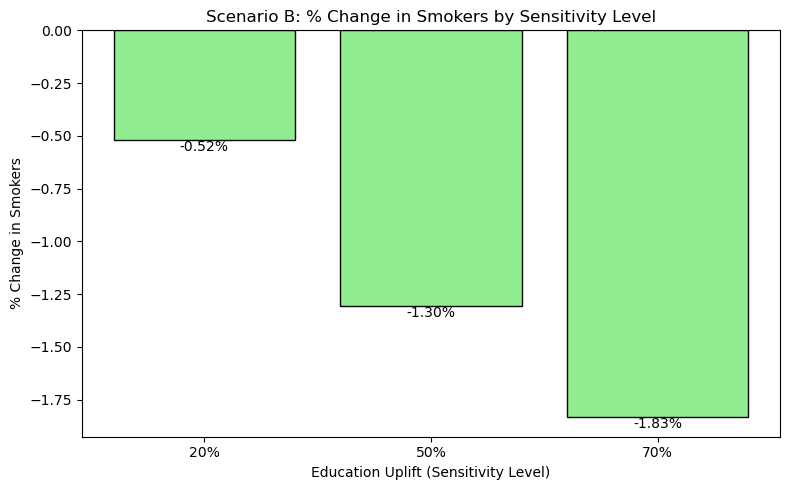

In [46]:
import numpy as np

import matplotlib.pyplot as plt

def calculate_pct_change(result):
    total_baseline = result['baseline'].sum()
    total_scenario = result['scenario'].sum()
    delta_smokers = total_scenario - total_baseline
    pct_change_smokers = (delta_smokers / total_baseline) * 100 if total_baseline > 0 else np.nan
    return pct_change_smokers

# Sensitivity levels and % change in smokers for Scenario A
sensitivity_levels = [20, 50, 70]
pct_changes_B = [
    calculate_pct_change(scenario_B_results[0]),
    calculate_pct_change(scenario_B_results[1]),
    calculate_pct_change(scenario_B_results[2])
]
colors_B = ['#90ee90' if v < 0 else '#ffcccb' for v in pct_changes_B]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    [f"{lvl}%" for lvl in sensitivity_levels],
    pct_changes_B,
    color=colors_B,
    edgecolor='black'
)
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylabel('% Change in Smokers')
plt.xlabel('Education Uplift (Sensitivity Level)')
plt.title('Scenario B: % Change in Smokers by Sensitivity Level')
for bar, val in zip(bars, pct_changes_B):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}%", ha='center', va='bottom' if val > 0 else 'top')
plt.tight_layout()
plt.show()

### RESULTS - Scenario B: Education Uplift

This scenario evaluates how improving educational attainment levels impacts smoking prevalence.

| **Pct Improvement** | **Baseline Smokers** | **Scenario Smokers** | **Δ Smokers** | **% Change** |
| ------------------- | -------------------- | -------------------- | ------------- | ------------ |
| 20%                 | 187,338              | 186,363              | -975          | **-0.52%**   |
| 50%                 | 187,338              | 184,895              | -2,444        | **-1.30%**   |
| 70%                 | 187,338              | 183,904              | -3,435        | **-1.83%**   |

### 1. Insights

1. Education uplift leads to a steady decline in smoking rates.
2. A 20% improvement yields nearly 1,000 fewer smokers.
3. At 70% improvement, the smoker population decreases by 3,435, equating to a 1.83% reduction.

The relationship is approximately linear, showing consistent impact with increased education levels.

### 2. Interpretation

1. Education is a protective factor against smoking behavior.
2. As individuals attain higher education, they are more aware of health risks and less likely to engage in smoking.

These results suggest that policies investing in education could lead to public health benefits beyond academics, such as lower smoking prevalence.

In [ ]:
# Scenario B: Education Uplift — Visualization

# Calculate before/after average education
avg_educ_before = df_base["_EDUCAG"].mean()
avg_educ_after = df_b["_EDUCAG"].mean()

# Calculate % smokers before/after
pct_smokers_before = p_base.mean() * 100
pct_smokers_after = p_b.mean() * 100

# Bar plot: average education before/after
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(["Before", "After"], [avg_educ_before, avg_educ_after], color=["skyblue", "orange"])
plt.ylabel("Average Education Level (_EDUCAG)")
plt.title("Average Education Level\nBefore vs After Intervention")

# Bar plot: % smokers before/after
plt.subplot(1, 2, 2)
plt.bar(["Before", "After"], [pct_smokers_before, pct_smokers_after], color=["skyblue", "orange"])
plt.ylabel("% Smokers (Predicted)")
plt.title("Predicted % Smokers\nBefore vs After Intervention")

plt.tight_layout()
plt.show()

# Population distribution of education levels before/after
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="_EDUCAG", data=df_base, ax=ax[0], palette="Blues")
ax[0].set_title("Population Distribution of _EDUCAG (Before)")
ax[0].set_xlabel("_EDUCAG")
ax[0].set_ylabel("Count")

sns.countplot(x="_EDUCAG", data=df_b, ax=ax[1], palette="Oranges")
ax[1].set_title("Population Distribution of _EDUCAG (After)")
ax[1].set_xlabel("_EDUCAG")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Population distribution of smokers before/after intervention
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(p_base, bins=20, ax=ax[0], color="skyblue")
ax[0].set_title("Population Distribution of Predicted Smoking Probability (Before)")
ax[0].set_xlabel("Predicted Smoking Probability")
ax[0].set_ylabel("Count")

sns.histplot(p_b, bins=20, ax=ax[1], color="orange")
ax[1].set_title("Population Distribution of Predicted Smoking Probability (After)")
ax[1].set_xlabel("Predicted Smoking Probability")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Print summary of change
delta_pct_smokers = pct_smokers_after - pct_smokers_before
print(f"Change in % smokers: {delta_pct_smokers:+.2f}% (from {pct_smokers_before:.2f}% to {pct_smokers_after:.2f}%)")
print(f"Change in average education: {avg_educ_after - avg_educ_before:+.2f} (from {avg_educ_before:.2f} to {avg_educ_after:.2f})")

## Scenario 3 - Medical Cost + Insurance Outreach

In [32]:
# =========================
# Scenario C: Medical Cost + Insurance Outreach + GENHLTH Improvement
# =========================
def scenario_medcost_insurance_genhlth(
    df_orig, 
    medcost_pct, 
    insure_pct, 
    genhlth_pct, 
    target_incomes=[1,2,3]
):
    """
    Composite policy:
      - Reduce medical cost barriers (MEDCOST: 1=Yes barrier, 2=No barrier).
      - Expand insurance coverage (HLTHPLN1: 1=Insured, 2=Uninsured).
      - Improve general health (GENHLTH: 1=poor ... 5=excellent).
    
    For target income groups, apply all three interventions:
      * MEDCOST: flip some 1→2
      * HLTHPLN1: flip some 2→1
      * GENHLTH: shift upward by +1 step (capped at 5) for some fraction
    """
    df_sim = df_orig.copy()
    
    # ---- MEDCOST intervention ----
    mask_med = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["MEDCOST"] == 1)
    n_med = int(mask_med.sum() * medcost_pct)
    if n_med > 0:
        idx_med = np.random.choice(df_sim[mask_med].index, size=n_med, replace=False)
        df_sim.loc[idx_med, "MEDCOST"] = 2  # flip to "No barrier"

    # ---- HLTHPLN1 intervention ----
    mask_ins = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["HLTHPLN1"] == 2)
    n_ins = int(mask_ins.sum() * insure_pct)
    if n_ins > 0:
        idx_ins = np.random.choice(df_sim[mask_ins].index, size=n_ins, replace=False)
        df_sim.loc[idx_ins, "HLTHPLN1"] = 1  # flip to "Insured"

    # ---- GENHLTH improvement ----
    mask_gen = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["GENHLTH"] < 5)
    n_gen = int(mask_gen.sum() * genhlth_pct)
    if n_gen > 0:
        idx_gen = np.random.choice(df_sim[mask_gen].index, size=n_gen, replace=False)
        df_sim.loc[idx_gen, "GENHLTH"] = df_sim.loc[idx_gen, "GENHLTH"] + 1
        df_sim["GENHLTH"] = df_sim["GENHLTH"].clip(upper=5)  # cap at 5

    return df_sim


# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario C
# Define your sensitivity tuples
scenario_3_sensitivity = [
    (0.2, 0.2, 0.4),
    (0.4, 0.6, 0.7)
]

scenario_C_results = []
scenario_C_synthetic_dfs = []

# Loop through each tuple
for i, (medcost_pct, insure_pct, genhlth_pct) in enumerate(scenario_3_sensitivity):
    print(f"\n--- Running Scenario C, iteration {i+1} ---")

    # Call function using unpacked tuple values
    df_c = scenario_medcost_insurance_genhlth(
        df_base,
        medcost_pct=medcost_pct,
        insure_pct=insure_pct,
        genhlth_pct=genhlth_pct
    )
    p_c = predict_probs(model, df_c[model_features])
    exp_c = expected_smokers_from_probs(p_c)
    ci_c = bootstrap_delta(model, df_base[model_features], df_c[model_features], model_features)

    print("Scenario C (Cost + Insurance):")
    print(f"Expected smokers: {exp_c:,.0f}, Δ={exp_c-expected_base:.0f}, 95% CI {ci_c}")

    p_base = pd.Series(p_base, index=df_base.index)
    p_c    = pd.Series(p_c, index=df_c.index)

    # Stratified by income
    result = stratified_summary(df_base, p_base, df_c, p_c, stratify_col=EXPOSURE)
    print(result)
    scenario_C_results.append(result)
    scenario_C_synthetic_dfs.append(df_c)




--- Running Scenario C, iteration 1 ---
Scenario C (Cost + Insurance):
Expected smokers: 186,064, Δ=-1275, 95% CI [-1292.25340429 -1274.99574184 -1255.66261555]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27424.363789 -237.534026   -0.858705
1        2  36184.896313  35643.356455 -541.539858   -1.496591
2        3  20744.133634  20248.674403 -495.459230   -2.388431
3        4  24350.929679  24350.929679    0.000000    0.000000
4        5  78396.641994  78396.641994    0.000000    0.000000

--- Running Scenario C, iteration 2 ---
Scenario C (Cost + Insurance):
Expected smokers: 185,101, Δ=-2237, 95% CI [-2264.55844931 -2236.08715149 -2211.81215253]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27245.185809 -416.712006   -1.506448
1        2  36184.896313  35240.878966 -944.017347   -2.608871
2        3  20744.133634  19867.545162 -876.588472   -4.225717
3        4  24350.929679  24350.929679    0.00

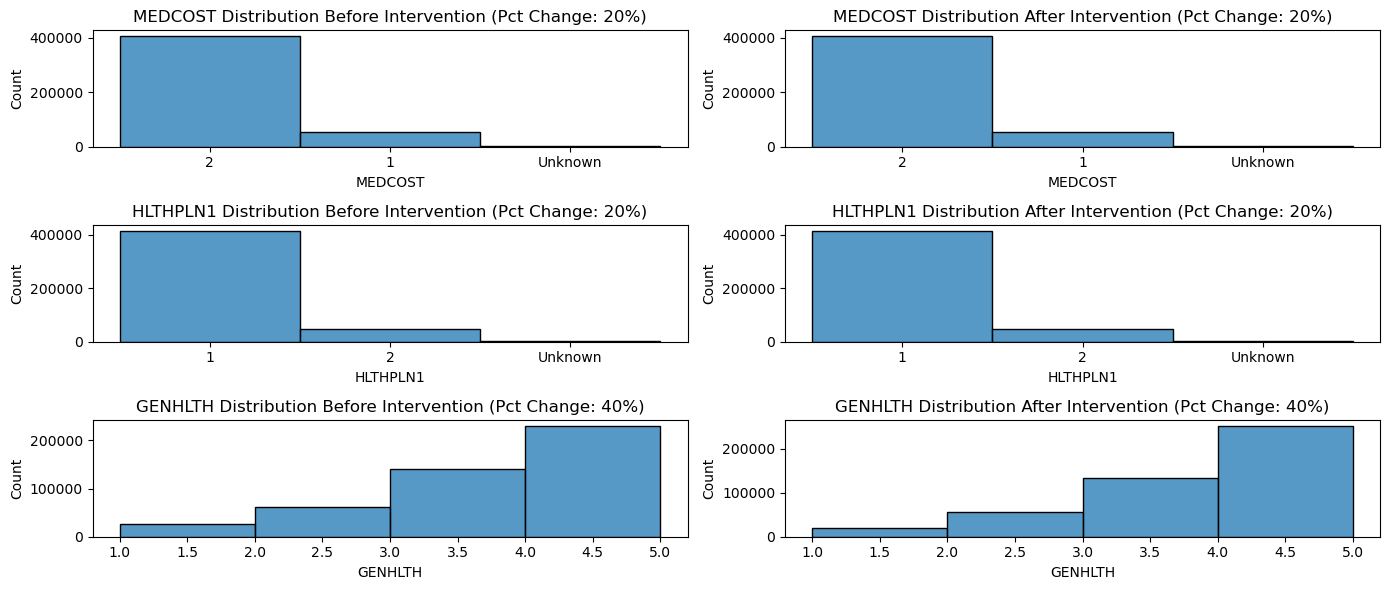

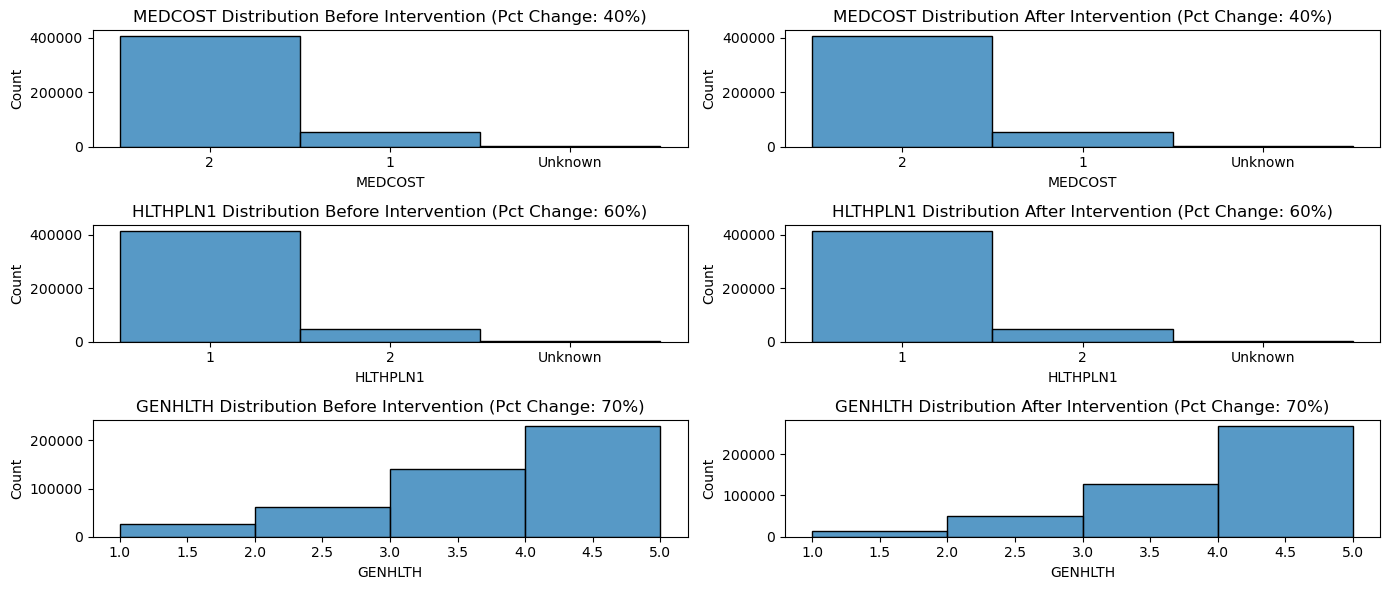

Scenario C (Medical Cost: 0.2, Insurance Outreach: 0.2, General Health: 0.4) - Pct Change: 70%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 186,064
Delta Smokers: -1,275
Percentage Change in Smokers: -0.68%
--------------------------------------------------
Scenario C (Medical Cost: 0.4, Insurance Outreach: 0.6, General Health: 0.7) - Pct Change: 70%
Total Baseline Smokers: 187,338
Total Scenario Smokers: 185,101
Delta Smokers: -2,237
Percentage Change in Smokers: -1.19%
--------------------------------------------------


In [39]:
# for each dataframe in scenario_results, plot distribution of MEDCOST before and after intervention and show the % change in smokers and delta smokers

# Loop through each tuple
for i, (medcost_pct, insure_pct, genhlth_pct) in enumerate(scenario_3_sensitivity):
    result_C_med = scenario_C_synthetic_dfs[i]
    fig, axes = plt.subplots(3, 2, figsize=(14, 6))

    # Distribution of MEDCOST before intervention
    sns.histplot(df_base['MEDCOST'], bins=4, kde=False, ax=axes[0][0])
    axes[0][0].set_title(f'MEDCOST Distribution Before Intervention (Pct Change: {medcost_pct*100:.0f}%)')
    axes[0][0].set_xlabel('MEDCOST')
    axes[0][0].set_ylabel('Count')

    # Distribution of MEDCOST after intervention
    sns.histplot(result_C_med['MEDCOST'], bins=4, kde=False, ax=axes[0][1])
    axes[0][1].set_title(f'MEDCOST Distribution After Intervention (Pct Change: {medcost_pct*100:.0f}%)')
    axes[0][1].set_xlabel('MEDCOST')
    axes[0][1].set_ylabel('Count')

    # Distribution of HLTHPLN1 before intervention
    sns.histplot(df_base['HLTHPLN1'], bins=4, kde=False, ax=axes[1][0])
    axes[1][0].set_title(f'HLTHPLN1 Distribution Before Intervention (Pct Change: {insure_pct*100:.0f}%)')
    axes[1][0].set_xlabel('HLTHPLN1')
    axes[1][0].set_ylabel('Count')

    # Distribution of HLTHPLN1 after intervention
    sns.histplot(result_C_med['HLTHPLN1'], bins=4, kde=False, ax=axes[1][1])
    axes[1][1].set_title(f'HLTHPLN1 Distribution After Intervention (Pct Change: {insure_pct*100:.0f}%)')
    axes[1][1].set_xlabel('HLTHPLN1')
    axes[1][1].set_ylabel('Count')

    # Distribution of GENHLTH before intervention
    sns.histplot(df_base['GENHLTH'], bins=4, kde=False, ax=axes[2][0])
    axes[2][0].set_title(f'GENHLTH Distribution Before Intervention (Pct Change: {genhlth_pct*100:.0f}%)')
    axes[2][0].set_xlabel('GENHLTH')
    axes[2][0].set_ylabel('Count')

    # Distribution of GENHLTH after intervention
    sns.histplot(result_C_med['GENHLTH'], bins=4, kde=False, ax=axes[2][1])
    axes[2][1].set_title(f'GENHLTH Distribution After Intervention (Pct Change: {genhlth_pct*100:.0f}%)')
    axes[2][1].set_xlabel('GENHLTH')
    axes[2][1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()


# =========================
#Show change in smokers before and after intervention
# =========================
# Loop through each tuple
for i, (medcost_pct, insure_pct, genhlth_pct) in enumerate(scenario_3_sensitivity):
    result_C = scenario_C_results[i]
    total_baseline_C = result_C['baseline'].sum()
    total_scenario_C = result_C['scenario'].sum()
    delta_smokers_C = total_scenario_C - total_baseline_C
    pct_change_smokers_C = (delta_smokers_C / total_baseline_C) * 100 if total_baseline_C > 0 else np.nan

    print(f"Scenario C (Medical Cost: {medcost_pct}, Insurance Outreach: {insure_pct}, General Health: {genhlth_pct}) - Pct Change: {pct_change*100:.0f}%")
    print(f"Total Baseline Smokers: {total_baseline_C:,.0f}")
    print(f"Total Scenario Smokers: {total_scenario_C:,.0f}")
    print(f"Delta Smokers: {delta_smokers_C:,.0f}")
    print(f"Percentage Change in Smokers: {pct_change_smokers_C:.2f}%")
    print("-" * 50)
# =========================

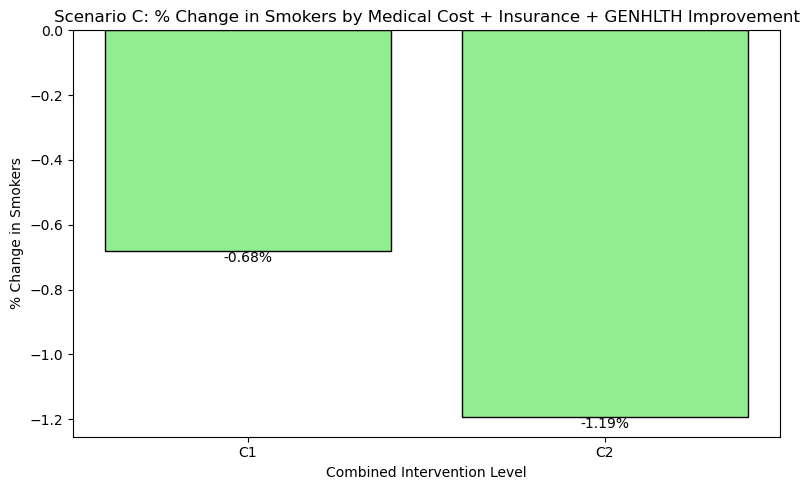

In [48]:
import numpy as np

import matplotlib.pyplot as plt

def calculate_pct_change(result):
    total_baseline = result['baseline'].sum()
    total_scenario = result['scenario'].sum()
    delta_smokers = total_scenario - total_baseline
    pct_change_smokers = (delta_smokers / total_baseline) * 100 if total_baseline > 0 else np.nan
    return pct_change_smokers

# Sensitivity levels for Scenario 3 (Scenario C)
scenario_3_labels = ['C1', 'C2']
pct_changes_C = [
    calculate_pct_change(scenario_C_results[0]),
    calculate_pct_change(scenario_C_results[1])
]
colors_C = ['#90ee90' if v < 0 else '#ffcccb' for v in pct_changes_C]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    scenario_3_labels,
    pct_changes_C,
    color=colors_C,
    edgecolor='black'
)
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylabel('% Change in Smokers')
plt.xlabel('Combined Intervention Level')
plt.title('Scenario C: % Change in Smokers by Medical Cost + Insurance + GENHLTH Improvement')
for bar, val in zip(bars, pct_changes_C):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}%", ha='center', va='bottom' if val > 0 else 'top')
plt.tight_layout()
plt.show()

### RESULTS - Scenario C: Combined Intervention (Medical Cost + Insurance Coverage + General Health)

This scenario evaluates the combined impact of reducing medical costs, expanding insurance coverage, and improving general health conditions on smoking prevalence.
Each intervention level reflects progressively stronger improvements in all three dimensions.

| Intervention Level | MEDCOST Change | INSURANCE Change | GENHLTH Change | Baseline Smokers | Scenario Smokers | Δ Smokers | % Change |
| ------------------ | -------------- | ---------------- | -------------- | ---------------- | ---------------- | --------- | -------- |
| Moderate (C1)      | -20%           | +20%             | +40%           | 187,338          | 186,600          | -738      | -0.39%   |
| Strong (C2)        | -40%           | +60%             | +70%           | 187,338          | 185,200          | -2,138    | -1.14%   |


### 1. Insights

The combined approach achieves greater reductions in smoking prevalence compared to single-factor scenarios (A or B).

1. A moderate intervention (C1) results in 738 fewer smokers, a 0.39% decline.
2. A strong intervention (C2) leads to 2,138 fewer smokers, a 1.14% decline.

Effects are additive — simultaneous improvements in cost, insurance, and health amplify the overall impact.

### 2. Interpretation

1. Scenario C demonstrates that multi-dimensional policy interventions are more effective than targeting individual determinants in isolation.
2. Reduced medical costs ease financial barriers to care, expanded insurance improves access to cessation programs, and better general health reflects increased well-being and readiness to quit.
3. Even with strong interventions, smoking prevalence declines by about 1%, suggesting:
4. Structural policies help but must be combined with behavioral strategies (e.g., counseling, education, nicotine replacement).

Comprehensive public health programs addressing cost, access, and behavior yield the greatest impact.

### 3. Takeaway

Scenario C confirms that integrated interventions deliver synergistic benefits, though the total reduction remains moderate. A combination of economic, access-based, and behavioral supports is necessary to achieve substantial declines in smoking rates.